# Gene Level Concordance

        ## Manuscript targets
        - `Results / Impact of trimming on the biological interpretation / Gene-level concordance`
- `Figure gene level concordance`

        ## Primary inputs
        - `share/results/biological/bio_concordance_binary.tsv`

        ## Rebuild scripts
        - `share/scripts/analysis/20_aggregate_loso_concordance_long_table.py`

        This notebook prefers the full local `data/` working set when it exists and falls back to the tiny `share/data/` example bundle otherwise.


## Inputs, methodology, and rebuild policy

The LOSO biological concordance table stores one record per SRR and method. This notebook isolates the gene-level endpoints used in the manuscript: global rank correlation of gene statistics and Jaccard overlap of thresholded DEG sets.


In [18]:
from __future__ import annotations

import math
import re
import subprocess
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
except ImportError:
    sns = None

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 120
SRR_PATTERN = re.compile(r"(SRR\d+)")


def find_repo_root() -> Path:
    start = Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "share").exists() and (candidate / "share" / "results").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the notebook working directory.")


REPO_ROOT = find_repo_root()
SHARE = REPO_ROOT / "share"
RESULTS = SHARE / "results"
TECH = RESULTS / "technical"
BIO = RESULTS / "biological"
SUPP = RESULTS / "supplementary"
SHARE_DATA = SHARE / "data"
LOCAL_DATA = REPO_ROOT / "data"
SCRIPTS = SHARE / "scripts"
NOTEBOOK_DB = SHARE / "notebooks" / "srr_queue.db"


def data_dir(name: str) -> Path:
    local = LOCAL_DATA / name
    if local.exists():
        return local
    return SHARE_DATA / name


def load_table(path: Path) -> pd.DataFrame:
    sep = "," if path.suffix == ".csv" else "\t"
    return pd.read_csv(path, sep=sep)


def run_script(script_rel: str, *args: str) -> None:
    script = REPO_ROOT / script_rel
    if not script.exists():
        raise FileNotFoundError(script)
    cmd = ["python3", str(script), *map(str, args)] if script.suffix == ".py" else ["bash", str(script), *map(str, args)]
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=REPO_ROOT)


def parse_fastqc_terminal_quality(fastqc_data_path: Path) -> float | None:
    rows: list[list[str]] = []
    in_section = False
    for line in fastqc_data_path.read_text(encoding="utf-8", errors="replace").splitlines():
        if line.startswith(">>Per base sequence quality"):
            in_section = True
            continue
        if in_section and line.startswith(">>END_MODULE"):
            break
        if in_section and line and not line.startswith("#"):
            rows.append(line.split("\t"))
    if not rows:
        return None
    means = []
    for row in rows:
        try:
            means.append(float(row[1]))
        except (IndexError, ValueError):
            continue
    if not means:
        return None
    return float(np.mean(means[-min(10, len(means)) :]))


def load_terminal_quality_table() -> pd.DataFrame:
    quality = load_table(TECH / "per_srr_quality.tsv")
    raw_dir = data_dir("flattened_fastqc_raw")
    rows = []
    if raw_dir.exists():
        for fastqc_data in raw_dir.glob("*/*_fastqc/fastqc_data.txt"):
            terminal_q = parse_fastqc_terminal_quality(fastqc_data)
            if terminal_q is None:
                continue
            project_id = fastqc_data.parents[1].name
            srr = fastqc_data.parent.name.removesuffix("_fastqc")
            if srr.endswith("_1") or srr.endswith("_2"):
                srr = srr[:-2]
            rows.append({
                "project_id": project_id,
                "SRR_ID": srr,
                "terminal_q_mean": terminal_q,
            })
    if rows:
        terminal = (
            pd.DataFrame(rows)
            .groupby(["project_id", "SRR_ID"], as_index=False)["terminal_q_mean"]
            .mean()
        )
        merged = quality.merge(terminal, on=["project_id", "SRR_ID"], how="left")
        merged["terminal_q_mean"] = merged["terminal_q_mean"].fillna(
            merged["Q_mean"] - merged["tail_quality_decay"]
        )
        return merged

    quality["terminal_q_mean"] = quality["Q_mean"] - quality["tail_quality_decay"]
    return quality


def srr_ids_from_tree(root: Path) -> set[str]:
    srrs: set[str] = set()
    if not root.exists():
        return srrs
    for path in root.rglob("*"):
        match = SRR_PATTERN.search(path.name) or SRR_PATTERN.search(path.as_posix())
        if match:
            srrs.add(match.group(1))
    return srrs


def flattened_dir_srr_sets(root: Path, cohort_projects: set[str] | None = None) -> dict[str, set[str]]:
    dir_sets: dict[str, set[str]] = {}
    if not root.exists():
        return dir_sets

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        dir_srrs: set[str] = set()
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            if cohort_projects is not None and project_dir.name not in cohort_projects:
                continue
            dir_srrs.update(srr_ids_from_tree(project_dir))
        dir_sets[flattened_dir.name] = dir_srrs
    return dir_sets


def collect_flattened_dir_audit(root: Path, cohort_projects: set[str] | None = None) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame(
            columns=[
                "flattened_dir",
                "projects_total",
                "unique_srrs_total",
                "projects_in_cohort",
                "unique_srrs_in_cohort",
                "projects_outside_cohort",
                "unique_srrs_outside_cohort",
                "outside_cohort_projects",
            ]
        )

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        project_srrs: dict[str, set[str]] = {}
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            project_srrs[project_dir.name] = srr_ids_from_tree(project_dir)

        all_srrs = set().union(*project_srrs.values()) if project_srrs else set()
        if cohort_projects is None:
            in_cohort = project_srrs
            out_cohort: dict[str, set[str]] = {}
        else:
            in_cohort = {k: v for k, v in project_srrs.items() if k in cohort_projects}
            out_cohort = {k: v for k, v in project_srrs.items() if k not in cohort_projects}

        in_srrs = set().union(*in_cohort.values()) if in_cohort else set()
        out_srrs = set().union(*out_cohort.values()) if out_cohort else set()

        rows.append(
            {
                "flattened_dir": flattened_dir.name,
                "projects_total": len(project_srrs),
                "unique_srrs_total": len(all_srrs),
                "projects_in_cohort": len(in_cohort),
                "unique_srrs_in_cohort": len(in_srrs),
                "projects_outside_cohort": len(out_cohort),
                "unique_srrs_outside_cohort": len(out_srrs),
                "outside_cohort_projects": ", ".join(sorted(out_cohort)) if out_cohort else "",
            }
        )

    return pd.DataFrame(rows)


In [19]:
bio = load_table(BIO / "bio_concordance_binary.tsv")
method_order = ["U", "A", "P5", "P10", "P20", "P35"]
bio["method"] = pd.Categorical(bio["method"], categories=method_order, ordered=True)
bio.head()


,project,SRR_ID,method,rho_gene,jaccard_deg,rho_pathway,jaccard_pathway,dir_concordance
0,PRJNA381757,SRR5420974,U,0.898417,0.614174,0.937287,0.979167,1.0
1,PRJNA381757,SRR5420974,A,0.898416,0.614174,0.943818,0.979167,1.0
2,PRJNA381757,SRR5420974,P5,0.898396,0.614292,0.946218,0.958333,1.0
3,PRJNA381757,SRR5420974,P10,0.898424,0.614256,0.942665,0.979167,1.0
4,PRJNA381757,SRR5420974,P20,0.885221,0.610415,0.958607,0.938776,1.0


In [20]:
summary = (
    bio.groupby("method")
    .agg(
        n=("SRR_ID", "size"),
        median_rho_gene=("rho_gene", "median"),
        min_rho_gene=("rho_gene", "min"),
        median_jaccard_deg=("jaccard_deg", "median"),
        min_jaccard_deg=("jaccard_deg", "min"),
    )
    .reset_index()
)
display(summary)


/var/folders/lw/lj39y98919j8mslvy2vtmqbm0000gn/T/ipykernel_53861/2595590451.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bio.groupby("method")


,method,n,median_rho_gene,min_rho_gene,median_jaccard_deg,min_jaccard_deg
0,U,824,0.973263,0.682574,0.371260,0.0
1,A,824,0.973202,0.482525,0.371361,0.0
2,P5,824,0.973182,0.644623,0.371389,0.0
3,P10,824,0.973234,0.644740,0.371788,0.0
4,P20,824,0.971454,0.483896,0.373045,0.0
5,P35,816,0.769451,-0.124801,0.201283,0.0


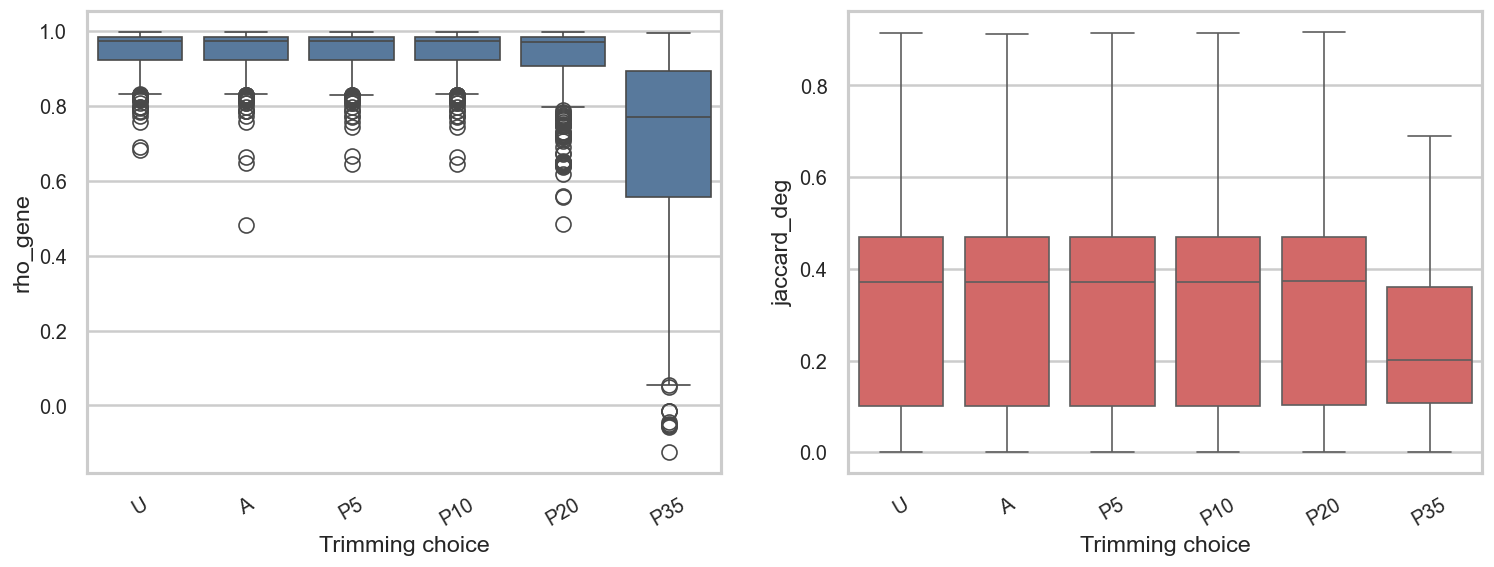

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if sns is not None:
    sns.boxplot(data=bio, x="method", y="rho_gene", order=method_order, ax=axes[0], color="#4C78A8")
    sns.boxplot(data=bio, x="method", y="jaccard_deg", order=method_order, ax=axes[1], color="#E45756")
else:
    axes[0].boxplot([bio.loc[bio["trimming choice"].eq(m), "rho_gene"].dropna() for m in method_order], tick_labels=method_order)
    axes[1].boxplot([bio.loc[bio["trimming choice"].eq(m), "jaccard_deg"].dropna() for m in method_order], tick_labels=method_order)

#axes[0].set_title("Gene-level concordance: Spearman rho")
axes[0].set_ylabel("rho_gene")
axes[0].set_xlabel("Trimming choice")

#axes[1].set_title("Gene-level concordance: DEG Jaccard")
axes[1].set_ylabel("jaccard_deg")
axes[1].set_xlabel("Trimming choice")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

#fig.tight_layout()

# Save vector versions
fig.savefig("gene_concordance_boxplots.pdf", bbox_inches="tight")
fig.savefig("gene_concordance_boxplots.svg", bbox_inches="tight")

# Save high-resolution raster version
fig.savefig("gene_concordance_boxplots.png", dpi=600, bbox_inches="tight")
plt.show()
